## Предварительные гипотезы

Линейная функция сходства ожидаемо является ядром, поскольку она непосредственно задаётся скалярным произведением. RBF-функция также ожидаемо удовлетворяет условию Мерсера при положительном значении параметра $\gamma$. Дельта-функция приводит к диагональной матрице Грама с неотрицательными элементами на диагонали, поэтому на конечной выборке она также должна проходить проверку.

Функция $K_{\neq}(x,z)$, равная единице при $x \neq z$ и нулю при $x=z$, ожидаемо может нарушать условие Мерсера: её матрица Грама имеет нулевую диагональ и положительные внедиагональные элементы. Сигмоидальная функция $\tanh(k_0 + k_1 x^Tz)$ не является универсально положительно полуопределённой; результат зависит от параметров, масштаба данных и геометрии выборки.

## Импорт библиотек и конфигурация

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.typing import NDArray
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
FloatArray = NDArray[np.float64]
IntArray = NDArray[np.int64]
GramFunction = Callable[[FloatArray], FloatArray]


@dataclass(frozen=True)
class ExperimentConfig:
    """Параметры численного эксперимента для проверки условия Мерсера."""

    seed: int = 42
    n_samples: int = 100
    dimension: int = 2
    cluster_std: float = 0.35
    rbf_gamma: float = 1.0
    sigmoid_k0: float = 0.0
    sigmoid_k1: float = 0.1
    tolerance: float = 1e-8
    random_tests: int = 500
    figure_size: tuple[float, float] = (7.0, 5.0)


@dataclass(frozen=True)
class KernelSpec:
    """Описание функции сходства через способ построения её матрицы Грама."""

    name: str
    gram_function: GramFunction


@dataclass(frozen=True)
class DatasetSpec:
    """Описание набора данных, используемого в эксперименте."""

    name: str
    features: FloatArray
    labels: IntArray
    label_names: Sequence[str]


@dataclass(frozen=True)
class MercerExperimentResult:
    """Результаты спектральной и случайной проверки условия Мерсера."""

    diagnostics: pd.DataFrame
    gram_matrices: dict[str, FloatArray]
    eigenvalues: dict[str, FloatArray]
    random_quadratic_forms: dict[str, FloatArray]

## Подготовка данных

In [ ]:
def generate_two_clouds(
    n_samples: int,
    dimension: int,
    cluster_std: float,
    seed: int,
) -> DatasetSpec:
    """Сгенерировать выборку из двух гауссовских облаков в пространстве R^d."""

    rng = np.random.default_rng(seed)
    first_cluster_size = n_samples // 2
    second_cluster_size = n_samples - first_cluster_size

    first_center = -np.ones(dimension, dtype=np.float64)
    second_center = np.ones(dimension, dtype=np.float64)

    first_cluster = rng.normal(
        loc=first_center,
        scale=cluster_std,
        size=(first_cluster_size, dimension),
    )
    second_cluster = rng.normal(
        loc=second_center,
        scale=cluster_std,
        size=(second_cluster_size, dimension),
    )

    features = np.vstack((first_cluster, second_cluster)).astype(np.float64)
    labels = np.concatenate(
        (
            np.zeros(first_cluster_size, dtype=np.int64),
            np.ones(second_cluster_size, dtype=np.int64),
        )
    )

    return DatasetSpec(
        name="Synthetic two-cloud sample",
        features=features,
        labels=labels,
        label_names=("First cloud", "Second cloud"),
    )


def load_standardized_iris() -> DatasetSpec:
    """Загрузить датасет Iris и стандартизовать его числовые признаки."""

    iris = load_iris()
    scaler = StandardScaler()
    features = scaler.fit_transform(np.asarray(iris.data, dtype=np.float64))
    labels = np.asarray(iris.target, dtype=np.int64)
    label_names = tuple(str(name) for name in iris.target_names)

    return DatasetSpec(
        name="Iris",
        features=features,
        labels=labels,
        label_names=label_names,
    )


def describe_dataset(dataset: DatasetSpec) -> pd.DataFrame:
    """Сформировать краткое табличное описание набора данных."""

    unique_labels, counts = np.unique(dataset.labels, return_counts=True)

    return pd.DataFrame(
        {
            "dataset": dataset.name,
            "objects": dataset.features.shape[0],
            "features": dataset.features.shape[1],
            "class": [dataset.label_names[int(label)] for label in unique_labels],
            "class_size": counts,
        }
    )


config = ExperimentConfig()
synthetic_dataset = generate_two_clouds(
    n_samples=config.n_samples,
    dimension=config.dimension,
    cluster_std=config.cluster_std,
    seed=config.seed,
)
iris_dataset = load_standardized_iris()

pd.concat(
    [describe_dataset(synthetic_dataset), describe_dataset(iris_dataset)],
    ignore_index=True,
)

,dataset,objects,features,class,class_size
0,Synthetic two-cloud sample,100,2,First cloud,50
1,Synthetic two-cloud sample,100,2,Second cloud,50
2,Iris,150,4,setosa,50
3,Iris,150,4,versicolor,50
4,Iris,150,4,virginica,50


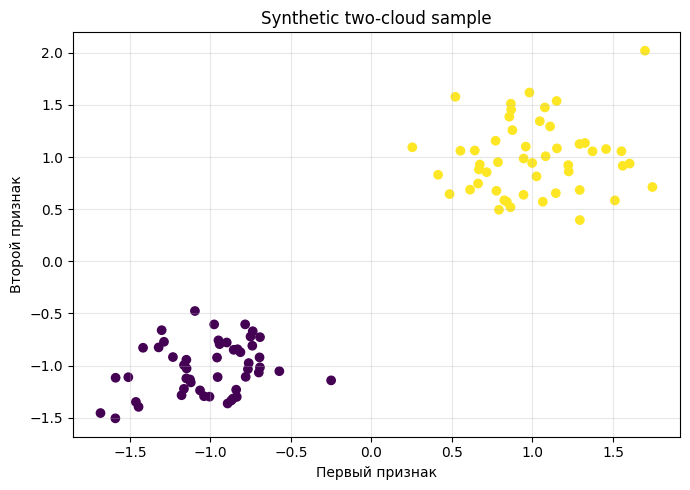

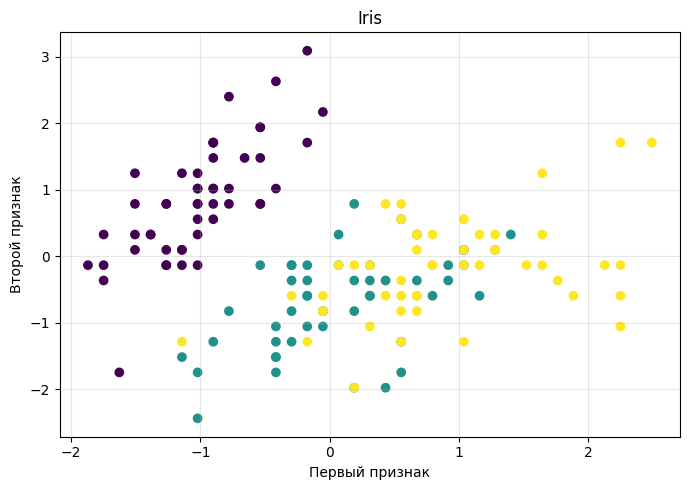

In [ ]:
def create_figure(config: ExperimentConfig) -> tuple[plt.Figure, plt.Axes]:
    """Создать фигуру фиксированного размера для единообразных графиков."""

    return plt.subplots(figsize=config.figure_size)


def plot_feature_projection(dataset: DatasetSpec, config: ExperimentConfig) -> None:
    """Построить двумерную проекцию данных по первым двум признакам."""

    if dataset.features.shape[1] < 2:
        raise ValueError("Для визуализации нужны как минимум два признака.")

    fig, ax = create_figure(config)
    ax.scatter(dataset.features[:, 0], dataset.features[:, 1], c=dataset.labels)
    ax.set_title(dataset.name)
    ax.set_xlabel("Первый признак")
    ax.set_ylabel("Второй признак")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


plot_feature_projection(synthetic_dataset, config)
plot_feature_projection(iris_dataset, config)

## Функции сходства и матрицы Грама



In [ ]:
def linear_gram(features: FloatArray) -> FloatArray:
    """Построить матрицу Грама для линейного ядра."""

    return features @ features.T


def rbf_gram_factory(gamma: float) -> GramFunction:
    """Создать функцию построения матрицы Грама для RBF-ядра."""

    def gram(features: FloatArray) -> FloatArray:
        """Построить RBF-матрицу Грама для заданной выборки."""

        squared_norms = np.sum(features ** 2, axis=1, keepdims=True)
        squared_distances = squared_norms + squared_norms.T - 2.0 * features @ features.T
        squared_distances = np.maximum(squared_distances, 0.0)
        return np.exp(-gamma * squared_distances)

    return gram


def delta_gram(features: FloatArray) -> FloatArray:
    """Построить матрицу Грама для дельта-функции сходства."""

    equal_objects = np.all(features[:, None, :] == features[None, :, :], axis=2)
    return equal_objects.astype(np.float64)


def not_equal_gram(features: FloatArray) -> FloatArray:
    """Построить матрицу Грама для функции несовпадения объектов."""

    return 1.0 - delta_gram(features)


def sigmoid_gram_factory(k0: float, k1: float) -> GramFunction:
    """Создать функцию построения матрицы Грама для сигмоидальной функции."""

    def gram(features: FloatArray) -> FloatArray:
        """Построить сигмоидальную матрицу Грама для заданной выборки."""

        return np.tanh(k0 + k1 * features @ features.T)

    return gram


def build_kernel_specs(config: ExperimentConfig) -> list[KernelSpec]:
    """Собрать список исследуемых функций сходства."""

    return [
        KernelSpec(name="Linear", gram_function=linear_gram),
        KernelSpec(name="RBF", gram_function=rbf_gram_factory(config.rbf_gamma)),
        KernelSpec(name="Delta", gram_function=delta_gram),
        KernelSpec(name="Not-equal", gram_function=not_equal_gram),
        KernelSpec(
            name="Sigmoid",
            gram_function=sigmoid_gram_factory(config.sigmoid_k0, config.sigmoid_k1),
        ),
    ]


kernel_specs = build_kernel_specs(config)
[kernel.name for kernel in kernel_specs]

['Linear', 'RBF', 'Delta', 'Not-equal', 'Sigmoid']

## Спектральная и случайная проверка условия Мерсера

Если матрица Грама имеет отрицательное собственное значение, то существует вектор $z$, для которого $z^TGz<0$. Поэтому отрицательное собственное значение является конечномерным свидетельством нарушения условия Мерсера на выбранной выборке.

Положительная полуопределённость на одной конечной выборке не доказывает условие Мерсера в полном виде, потому что теорема требует выполнения условия для любой конечной выборки из пространства объектов.

In [ ]:
def symmetrize(matrix: FloatArray) -> FloatArray:
    """Вернуть симметричную часть квадратной матрицы."""

    return 0.5 * (matrix + matrix.T)


def gram_eigenvalues(matrix: FloatArray) -> FloatArray:
    """Вычислить собственные значения симметричной части матрицы Грама."""

    return np.linalg.eigvalsh(symmetrize(matrix))


def random_quadratic_forms(
    matrix: FloatArray,
    n_tests: int,
    seed: int,
) -> FloatArray:
    """Вычислить значения z^T G z для случайных единичных векторов z."""

    rng = np.random.default_rng(seed)
    vectors = rng.normal(size=(n_tests, matrix.shape[0]))
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    unit_vectors = vectors / np.maximum(norms, np.finfo(np.float64).eps)
    symmetric_matrix = symmetrize(matrix)

    return np.einsum("bi,ij,bj->b", unit_vectors, symmetric_matrix, unit_vectors)


def diagnose_kernel(
    dataset: DatasetSpec,
    kernel_spec: KernelSpec,
    tolerance: float,
    n_random_tests: int,
    seed: int,
) -> tuple[dict[str, object], FloatArray, FloatArray, FloatArray]:
    """Выполнить диагностику условия Мерсера для одной функции сходства."""

    matrix = kernel_spec.gram_function(dataset.features)
    eigenvalues = gram_eigenvalues(matrix)
    quadratic_forms = random_quadratic_forms(
        matrix=matrix,
        n_tests=n_random_tests,
        seed=seed,
    )

    min_eigenvalue = float(np.min(eigenvalues))
    negative_eigenvalues = int(np.sum(eigenvalues < -tolerance))
    asymmetry = float(np.linalg.norm(matrix - matrix.T, ord="fro"))
    min_quadratic_form = float(np.min(quadratic_forms))

    row = {
        "dataset": dataset.name,
        "kernel": kernel_spec.name,
        "asymmetry_frobenius": asymmetry,
        "lambda_min": min_eigenvalue,
        "negative_eigenvalues": negative_eigenvalues,
        "spectral_mercer_passed": bool(min_eigenvalue >= -tolerance),
        "min_random_zTGz": min_quadratic_form,
        "random_test_passed": bool(min_quadratic_form >= -tolerance),
    }

    return row, matrix, eigenvalues, quadratic_forms


def run_mercer_experiment(
    dataset: DatasetSpec,
    kernel_specs: Sequence[KernelSpec],
    config: ExperimentConfig,
) -> MercerExperimentResult:
    """Провести проверку условия Мерсера для всех выбранных функций сходства."""

    rows: list[dict[str, object]] = []
    gram_matrices: dict[str, FloatArray] = {}
    eigenvalues: dict[str, FloatArray] = {}
    random_forms: dict[str, FloatArray] = {}

    for index, kernel_spec in enumerate(kernel_specs):
        row, matrix, spectrum, forms = diagnose_kernel(
            dataset=dataset,
            kernel_spec=kernel_spec,
            tolerance=config.tolerance,
            n_random_tests=config.random_tests,
            seed=config.seed + index,
        )
        rows.append(row)
        gram_matrices[kernel_spec.name] = matrix
        eigenvalues[kernel_spec.name] = spectrum
        random_forms[kernel_spec.name] = forms

    diagnostics = pd.DataFrame(rows)

    return MercerExperimentResult(
        diagnostics=diagnostics,
        gram_matrices=gram_matrices,
        eigenvalues=eigenvalues,
        random_quadratic_forms=random_forms,
    )

In [ ]:
synthetic_result = run_mercer_experiment(
    dataset=synthetic_dataset,
    kernel_specs=kernel_specs,
    config=config,
)
iris_result = run_mercer_experiment(
    dataset=iris_dataset,
    kernel_specs=kernel_specs,
    config=config,
)

pd.concat(
    [synthetic_result.diagnostics, iris_result.diagnostics],
    ignore_index=True,
)

,dataset,kernel,asymmetry_frobenius,lambda_min,negative_eigenvalues,spectral_mercer_passed,min_random_zTGz,random_test_passed
0,Synthetic two-cloud sample,Linear,0.000000e+00,-5.538404e-14,0,True,0.001843,True
1,Synthetic two-cloud sample,RBF,0.000000e+00,-1.043826e-15,0,True,0.059313,True
2,Synthetic two-cloud sample,Delta,0.000000e+00,1.000000e+00,0,True,1.000000,True
3,Synthetic two-cloud sample,Not-equal,0.000000e+00,-1.000000e+00,99,False,-0.999983,False
4,Synthetic two-cloud sample,Sigmoid,1.717373e-15,-9.077263e-02,7,False,-0.007982,False
5,Iris,Linear,0.000000e+00,-1.625917e-13,0,True,0.050098,True
6,Iris,RBF,0.000000e+00,4.737758e-17,0,True,0.352351,True
7,Iris,Delta,0.000000e+00,0.000000e+00,0,True,0.954191,True
8,Iris,Not-equal,0.000000e+00,-1.986754e+00,148,False,-1.029375,False
9,Iris,Sigmoid,3.428536e-15,-6.537464e-01,51,False,-0.030580,False


## Визуализация спектров и случайных квадратичных форм

In [ ]:
def plot_eigenvalue_spectra(
    eigenvalues_by_kernel: Mapping[str, FloatArray],
    title: str,
    config: ExperimentConfig,
) -> None:
    """Построить спектры матриц Грама для набора функций сходства."""

    fig, ax = create_figure(config)

    for kernel_name, values in eigenvalues_by_kernel.items():
        sorted_values = np.sort(values)
        ax.plot(
            np.arange(1, len(sorted_values) + 1),
            sorted_values,
            marker="o",
            linewidth=1,
            markersize=3,
            label=kernel_name,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Индекс собственного значения")
    ax.set_ylabel("Собственное значение")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def summarize_random_tests(random_forms: Mapping[str, FloatArray], dataset_name: str) -> pd.DataFrame:
    """Сформировать сводку случайных квадратичных форм."""

    rows: list[dict[str, float | str]] = []

    for kernel_name, values in random_forms.items():
        rows.append(
            {
                "dataset": dataset_name,
                "kernel": kernel_name,
                "min": float(np.min(values)),
                "q01": float(np.quantile(values, 0.01)),
                "median": float(np.median(values)),
                "mean": float(np.mean(values)),
                "q99": float(np.quantile(values, 0.99)),
                "max": float(np.max(values)),
            }
        )

    return pd.DataFrame(rows)


def plot_random_quadratic_forms(
    random_forms: Mapping[str, FloatArray],
    title: str,
    config: ExperimentConfig,
) -> None:
    """Построить эмпирические функции распределения значений z^T G z."""

    fig, ax = create_figure(config)

    for kernel_name, values in random_forms.items():
        sorted_values = np.sort(values)
        probabilities = np.linspace(0.0, 1.0, len(sorted_values))
        ax.plot(sorted_values, probabilities, linewidth=1, label=kernel_name)

    ax.axvline(0.0, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("$z^T G z$")
    ax.set_ylabel("Эмпирическая вероятность")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

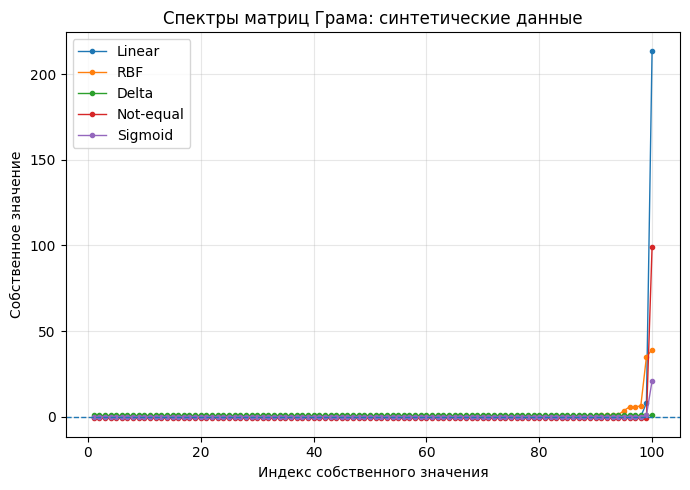

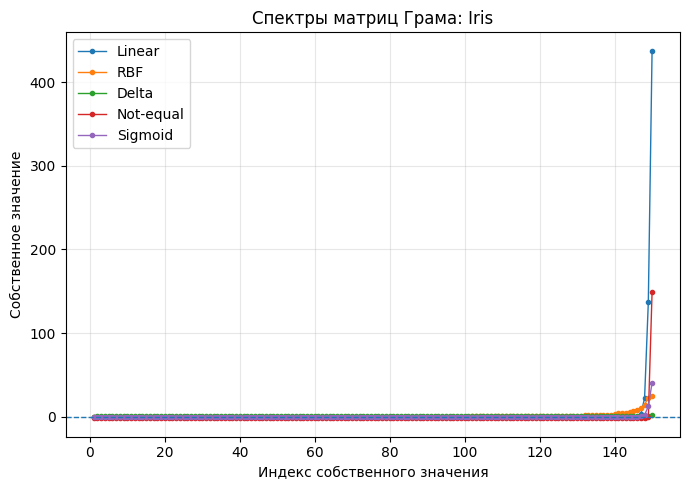

In [ ]:
plot_eigenvalue_spectra(
    synthetic_result.eigenvalues,
    "Спектры матриц Грама: синтетические данные",
    config,
)
plot_eigenvalue_spectra(
    iris_result.eigenvalues,
    "Спектры матриц Грама: Iris",
    config,
)

In [ ]:
random_summary = pd.concat(
    [
        summarize_random_tests(synthetic_result.random_quadratic_forms, synthetic_dataset.name),
        summarize_random_tests(iris_result.random_quadratic_forms, iris_dataset.name),
    ],
    ignore_index=True,
)

random_summary

,dataset,kernel,min,q01,median,mean,q99,max
0,Synthetic two-cloud sample,Linear,0.001843,0.010667,1.082928,2.318134,14.536735,20.750841
1,Synthetic two-cloud sample,RBF,0.059313,0.145202,0.789682,1.011980,3.418384,4.820340
2,Synthetic two-cloud sample,Delta,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Synthetic two-cloud sample,Not-equal,-0.999983,-0.999762,-0.551903,0.036288,5.522507,9.961339
4,Synthetic two-cloud sample,Sigmoid,-0.007982,0.000217,0.101740,0.219890,1.341712,2.257741
5,Iris,Linear,0.050098,0.138027,2.592461,3.951586,21.263506,29.585156
6,Iris,RBF,0.352351,0.445308,0.932248,1.007311,2.170443,2.856363
7,Iris,Delta,0.954191,0.970203,0.999986,1.000437,1.036243,1.052230
8,Iris,Not-equal,-1.029375,-1.005263,-0.535689,-0.020497,5.698602,8.604890
9,Iris,Sigmoid,-0.030580,-0.012173,0.238666,0.342675,1.635623,2.589933


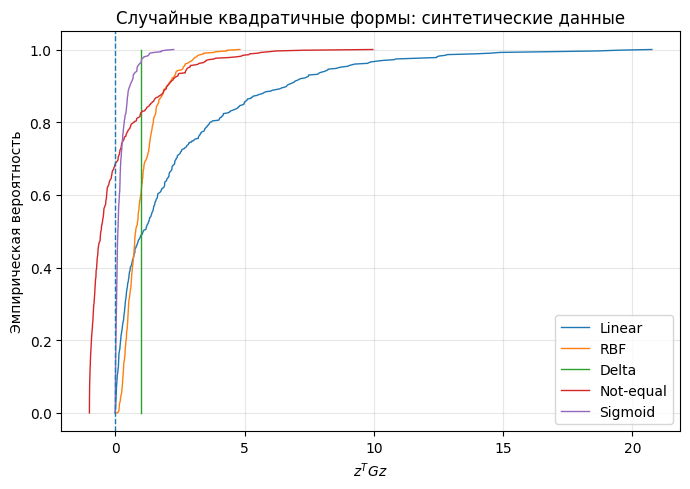

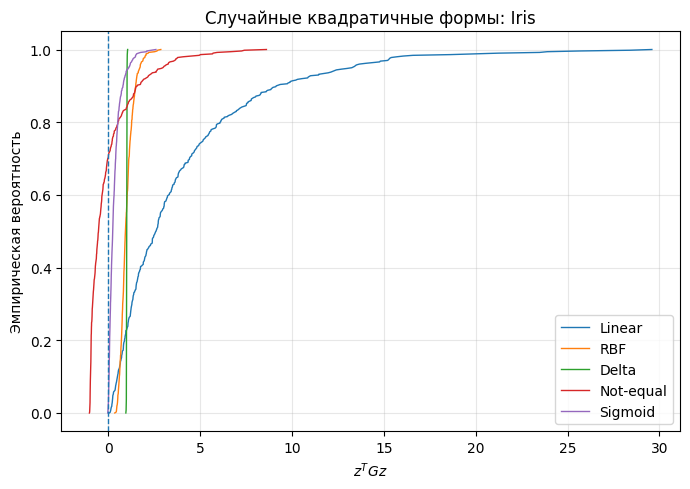

In [ ]:
plot_random_quadratic_forms(
    synthetic_result.random_quadratic_forms,
    "Случайные квадратичные формы: синтетические данные",
    config,
)
plot_random_quadratic_forms(
    iris_result.random_quadratic_forms,
    "Случайные квадратичные формы: Iris",
    config,
)

## Параметрическое исследование сигмоидальной функции

Для сигмоидальной функции проверяется сетка параметров $k_0 \in \{-1,0,1\}$ и $k_1 \in \{-1,0.1,1\}$.

In [ ]:
def evaluate_sigmoid_grid(
    dataset: DatasetSpec,
    k0_values: Sequence[float],
    k1_values: Sequence[float],
    tolerance: float,
) -> pd.DataFrame:
    """Вычислить минимальные собственные значения для сетки параметров сигмоидальной функции."""

    rows: list[dict[str, float | int | bool | str]] = []

    for k0 in k0_values:
        for k1 in k1_values:
            matrix = sigmoid_gram_factory(k0=k0, k1=k1)(dataset.features)
            eigenvalues = gram_eigenvalues(matrix)
            min_eigenvalue = float(np.min(eigenvalues))

            rows.append(
                {
                    "dataset": dataset.name,
                    "k0": float(k0),
                    "k1": float(k1),
                    "lambda_min": min_eigenvalue,
                    "negative_eigenvalues": int(np.sum(eigenvalues < tolerance * -1.0)),
                    "spectral_mercer_passed": bool(min_eigenvalue >= -tolerance),
                }
            )

    return pd.DataFrame(rows)


def plot_sigmoid_heatmap(
    grid_result: pd.DataFrame,
    title: str,
    config: ExperimentConfig,
) -> None:
    """Построить тепловую карту минимальных собственных значений для сигмоидальной функции."""

    pivot = grid_result.pivot(index="k0", columns="k1", values="lambda_min")
    values = pivot.to_numpy()

    fig, ax = create_figure(config)
    image = ax.imshow(values, aspect="auto")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_xticklabels([f"{value:g}" for value in pivot.columns])
    ax.set_yticklabels([f"{value:g}" for value in pivot.index])
    ax.set_xlabel("$k_1$")
    ax.set_ylabel("$k_0$")
    ax.set_title(title)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f"{values[i, j]:.2e}", ha="center", va="center")

    fig.colorbar(image, ax=ax, label="$\\lambda_{min}$")
    fig.tight_layout()
    plt.show()

In [ ]:
k0_values = [-1.0, 0.0, 1.0]
k1_values = [-1.0, 0.1, 1.0]

synthetic_sigmoid_grid = evaluate_sigmoid_grid(
    dataset=synthetic_dataset,
    k0_values=k0_values,
    k1_values=k1_values,
    tolerance=config.tolerance,
)
iris_sigmoid_grid = evaluate_sigmoid_grid(
    dataset=iris_dataset,
    k0_values=k0_values,
    k1_values=k1_values,
    tolerance=config.tolerance,
)

pd.concat([synthetic_sigmoid_grid, iris_sigmoid_grid], ignore_index=True)

,dataset,k0,k1,lambda_min,negative_eigenvalues,spectral_mercer_passed
0,Synthetic two-cloud sample,-1.0,-1.0,-83.596102,36,False
1,Synthetic two-cloud sample,-1.0,0.1,-74.710242,13,False
2,Synthetic two-cloud sample,-1.0,1.0,-21.162121,34,False
3,Synthetic two-cloud sample,0.0,-1.0,-93.873472,17,False
4,Synthetic two-cloud sample,0.0,0.1,-0.090773,7,False
5,Synthetic two-cloud sample,0.0,1.0,-2.136356,17,False
6,Synthetic two-cloud sample,1.0,-1.0,-83.628817,36,False
7,Synthetic two-cloud sample,1.0,0.1,-0.326433,9,False
8,Synthetic two-cloud sample,1.0,1.0,-4.183691,34,False
9,Iris,-1.0,-1.0,-116.352580,74,False


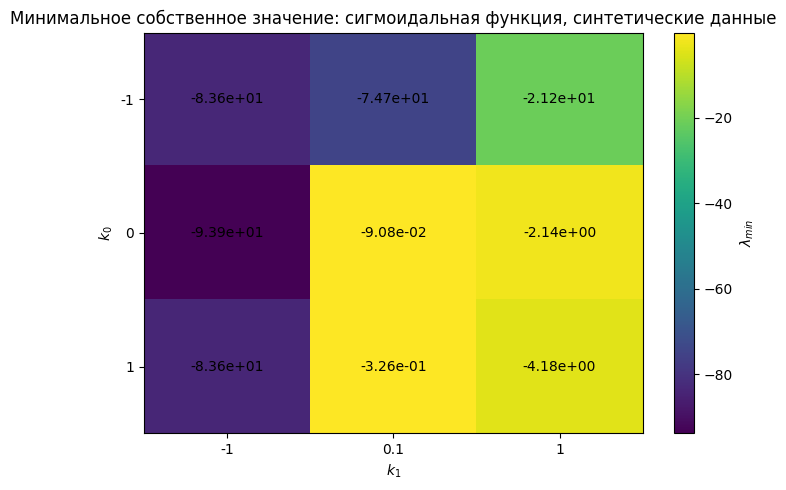

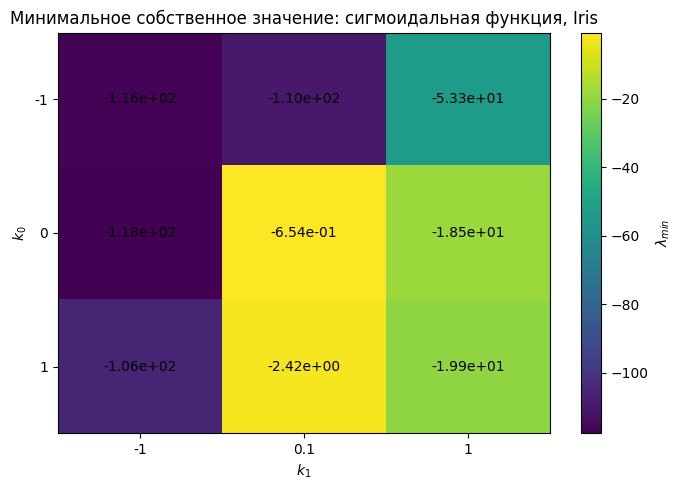

In [ ]:
plot_sigmoid_heatmap(
    synthetic_sigmoid_grid,
    "Минимальное собственное значение: сигмоидальная функция, синтетические данные",
    config,
)
plot_sigmoid_heatmap(
    iris_sigmoid_grid,
    "Минимальное собственное значение: сигмоидальная функция, Iris",
    config,
)

## Зависимость от размера выборки

Для синтетических данных используется несколько размеров выборки. Для Iris дополнительно рассматриваются стратифицированные подвыборки, поскольку полный датасет содержит 150 объектов.

In [ ]:
def stratified_subset(dataset: DatasetSpec, n_samples: int, seed: int) -> DatasetSpec:
    """Построить стратифицированную подвыборку заданного размера."""

    if n_samples > dataset.features.shape[0]:
        raise ValueError("Размер подвыборки не должен превышать размер исходного датасета.")

    rng = np.random.default_rng(seed)
    unique_labels = np.unique(dataset.labels)
    base_count = n_samples // len(unique_labels)
    remainder = n_samples % len(unique_labels)
    selected_indices: list[int] = []

    for position, label in enumerate(unique_labels):
        label_indices = np.flatnonzero(dataset.labels == label)
        target_count = base_count + int(position < remainder)
        chosen = rng.choice(label_indices, size=target_count, replace=False)
        selected_indices.extend(int(index) for index in chosen)

    selected_indices_array = np.asarray(selected_indices, dtype=np.int64)
    rng.shuffle(selected_indices_array)

    return DatasetSpec(
        name=f"{dataset.name}, n={n_samples}",
        features=dataset.features[selected_indices_array],
        labels=dataset.labels[selected_indices_array],
        label_names=dataset.label_names,
    )


def spectral_sample_size_diagnostics(
    dataset: DatasetSpec,
    kernel_specs: Sequence[KernelSpec],
    tolerance: float,
    source: str,
    n_samples: int,
) -> pd.DataFrame:
    """Вычислить спектральные показатели для одной выборки заданного размера."""

    rows: list[dict[str, object]] = []

    for kernel_spec in kernel_specs:
        matrix = kernel_spec.gram_function(dataset.features)
        eigenvalues = gram_eigenvalues(matrix)
        min_eigenvalue = float(np.min(eigenvalues))
        rows.append(
            {
                "dataset": dataset.name,
                "n_samples": n_samples,
                "source": source,
                "kernel": kernel_spec.name,
                "asymmetry_frobenius": float(np.linalg.norm(matrix - matrix.T, ord="fro")),
                "lambda_min": min_eigenvalue,
                "negative_eigenvalues": int(np.sum(eigenvalues < -tolerance)),
                "spectral_mercer_passed": bool(min_eigenvalue >= -tolerance),
            }
        )

    return pd.DataFrame(rows)


def evaluate_synthetic_sample_sizes(
    sample_sizes: Sequence[int],
    base_config: ExperimentConfig,
) -> pd.DataFrame:
    """Проверить функции сходства на синтетических выборках разных размеров."""

    tables: list[pd.DataFrame] = []

    for n_samples in sample_sizes:
        local_config = ExperimentConfig(
            seed=base_config.seed,
            n_samples=n_samples,
            dimension=base_config.dimension,
            cluster_std=base_config.cluster_std,
            rbf_gamma=base_config.rbf_gamma,
            sigmoid_k0=base_config.sigmoid_k0,
            sigmoid_k1=base_config.sigmoid_k1,
            tolerance=base_config.tolerance,
            random_tests=base_config.random_tests,
            figure_size=base_config.figure_size,
        )
        dataset = generate_two_clouds(
            n_samples=n_samples,
            dimension=local_config.dimension,
            cluster_std=local_config.cluster_std,
            seed=local_config.seed,
        )
        tables.append(
            spectral_sample_size_diagnostics(
                dataset=dataset,
                kernel_specs=build_kernel_specs(local_config),
                tolerance=local_config.tolerance,
                source="synthetic",
                n_samples=n_samples,
            )
        )

    return pd.concat(tables, ignore_index=True)


def evaluate_iris_sample_sizes(
    dataset: DatasetSpec,
    sample_sizes: Sequence[int],
    base_config: ExperimentConfig,
) -> pd.DataFrame:
    """Проверить функции сходства на стратифицированных подвыборках Iris."""

    tables: list[pd.DataFrame] = []

    for n_samples in sample_sizes:
        subset = stratified_subset(dataset, n_samples=n_samples, seed=base_config.seed + n_samples)
        tables.append(
            spectral_sample_size_diagnostics(
                dataset=subset,
                kernel_specs=build_kernel_specs(base_config),
                tolerance=base_config.tolerance,
                source="iris",
                n_samples=n_samples,
            )
        )

    return pd.concat(tables, ignore_index=True)


def plot_lambda_min_by_sample_size(
    sample_size_result: pd.DataFrame,
    title: str,
    config: ExperimentConfig,
) -> None:
    """Построить зависимость минимального собственного значения от размера выборки."""

    fig, ax = create_figure(config)

    for kernel_name, group in sample_size_result.groupby("kernel"):
        ordered_group = group.sort_values("n_samples")
        ax.plot(
            ordered_group["n_samples"],
            ordered_group["lambda_min"],
            marker="o",
            linewidth=1,
            markersize=4,
            label=kernel_name,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Размер выборки")
    ax.set_ylabel("$\\lambda_{min}(G)$")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

In [ ]:
synthetic_sample_size_result = evaluate_synthetic_sample_sizes(
    sample_sizes=[20, 50, 100, 200],
    base_config=config,
)
iris_sample_size_result = evaluate_iris_sample_sizes(
    dataset=iris_dataset,
    sample_sizes=[30, 60, 100, 150],
    base_config=config,
)

pd.concat([synthetic_sample_size_result, iris_sample_size_result], ignore_index=True)

,dataset,n_samples,source,kernel,asymmetry_frobenius,lambda_min,negative_eigenvalues,spectral_mercer_passed
0,Synthetic two-cloud sample,20,synthetic,Linear,0.000000e+00,-3.713941e-15,0,True
1,Synthetic two-cloud sample,20,synthetic,RBF,0.000000e+00,2.389127e-07,0,True
2,Synthetic two-cloud sample,20,synthetic,Delta,0.000000e+00,1.000000e+00,0,True
3,Synthetic two-cloud sample,20,synthetic,Not-equal,0.000000e+00,-1.000000e+00,19,False
4,Synthetic two-cloud sample,20,synthetic,Sigmoid,3.347971e-16,-1.456658e-02,5,False
5,Synthetic two-cloud sample,50,synthetic,Linear,0.000000e+00,-1.472902e-14,0,True
6,Synthetic two-cloud sample,50,synthetic,RBF,0.000000e+00,5.581391e-11,0,True
7,Synthetic two-cloud sample,50,synthetic,Delta,0.000000e+00,1.000000e+00,0,True
8,Synthetic two-cloud sample,50,synthetic,Not-equal,0.000000e+00,-1.000000e+00,49,False
9,Synthetic two-cloud sample,50,synthetic,Sigmoid,7.106864e-16,-2.214023e-02,5,False


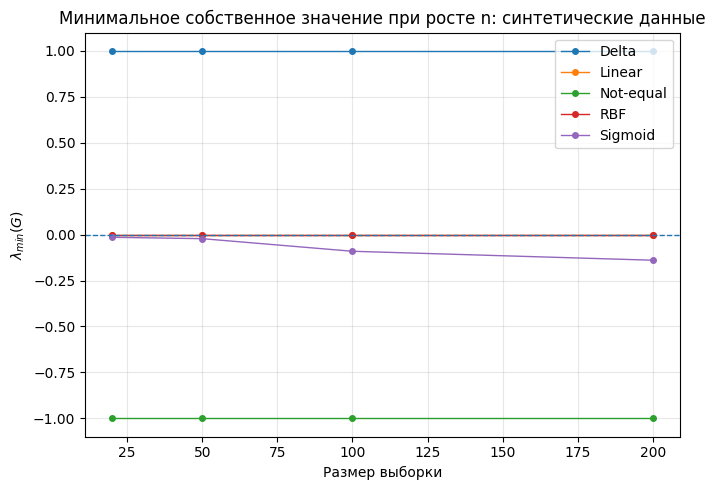

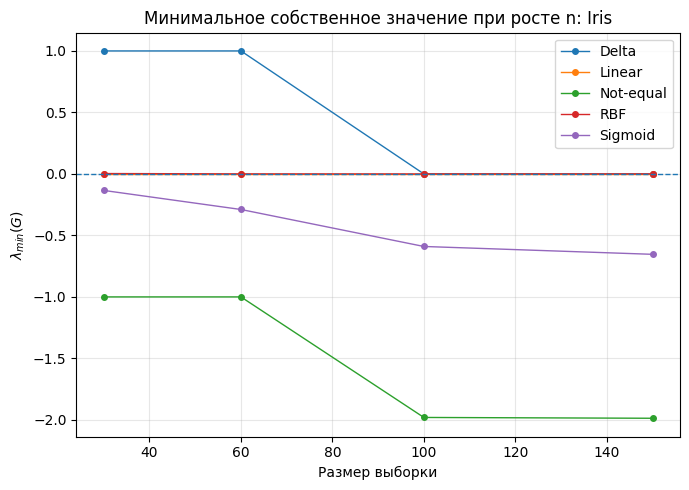

In [ ]:
plot_lambda_min_by_sample_size(
    synthetic_sample_size_result,
    "Минимальное собственное значение при росте n: синтетические данные",
    config,
)
plot_lambda_min_by_sample_size(
    iris_sample_size_result,
    "Минимальное собственное значение при росте n: Iris",
    config,
)

## Спектральная факторизация и разложение Холецкого


In [ ]:
def spectral_factor(
    matrix: FloatArray,
    tolerance: float,
) -> FloatArray:
    """Построить спектральный множитель по положительным собственным значениям."""

    symmetric_matrix = symmetrize(matrix)
    eigenvalues, eigenvectors = np.linalg.eigh(symmetric_matrix)
    positive_mask = eigenvalues > tolerance

    if not np.any(positive_mask):
        return np.zeros((matrix.shape[0], 0), dtype=np.float64)

    positive_eigenvalues = eigenvalues[positive_mask]
    positive_eigenvectors = eigenvectors[:, positive_mask]

    return positive_eigenvectors * np.sqrt(positive_eigenvalues)


def cholesky_factor_with_jitter(
    matrix: FloatArray,
    tolerance: float,
    jitter: float = 1e-10,
) -> FloatArray:
    """Вычислить фактор Холецкого после малой диагональной регуляризации."""

    symmetric_matrix = symmetrize(matrix)
    min_eigenvalue = float(np.min(np.linalg.eigvalsh(symmetric_matrix)))

    if min_eigenvalue < -tolerance:
        raise ValueError("Матрица не является численно положительно полуопределённой.")

    regularization = max(jitter, -min_eigenvalue + jitter)
    return np.linalg.cholesky(symmetric_matrix + regularization * np.eye(matrix.shape[0]))


def evaluate_factorizations(
    experiment: MercerExperimentResult,
    config: ExperimentConfig,
    dataset_name: str,
) -> pd.DataFrame:
    """Оценить ошибки спектральной факторизации и регуляризованного разложения Холецкого."""

    rows: list[dict[str, object]] = []

    for _, diagnostic in experiment.diagnostics.iterrows():
        kernel_name = str(diagnostic["kernel"])
        matrix = experiment.gram_matrices[kernel_name]

        if bool(diagnostic["spectral_mercer_passed"]):
            factor = spectral_factor(matrix, config.tolerance)
            spectral_reconstruction = factor @ factor.T
            spectral_error = float(np.linalg.norm(symmetrize(matrix) - spectral_reconstruction, ord="fro"))

            cholesky_factor = cholesky_factor_with_jitter(matrix, config.tolerance)
            cholesky_reconstruction = cholesky_factor @ cholesky_factor.T
            cholesky_error = float(np.linalg.norm(symmetrize(matrix) - cholesky_reconstruction, ord="fro"))

            rows.append(
                {
                    "dataset": dataset_name,
                    "kernel": kernel_name,
                    "spectral_factor_rank": factor.shape[1],
                    "spectral_reconstruction_error": spectral_error,
                    "cholesky_reconstruction_error": cholesky_error,
                }
            )

    return pd.DataFrame(rows)


factorization_result = pd.concat(
    [
        evaluate_factorizations(synthetic_result, config, synthetic_dataset.name),
        evaluate_factorizations(iris_result, config, iris_dataset.name),
    ],
    ignore_index=True,
)

factorization_result

,dataset,kernel,spectral_factor_rank,spectral_reconstruction_error,cholesky_reconstruction_error
0,Synthetic two-cloud sample,Linear,2,7.071537e-14,1.000554e-09
1,Synthetic two-cloud sample,RBF,60,1.469527e-08,1.000011e-09
2,Synthetic two-cloud sample,Delta,100,0.000000e+00,1.000000e-09
3,Iris,Linear,4,5.103477e-13,1.226736e-09
4,Iris,RBF,149,1.004248e-13,1.224745e-09
5,Iris,Delta,149,0.000000e+00,1.224745e-09


## Двумерное спектральное вложение объектов



In [ ]:
def spectral_embedding_from_gram(
    matrix: FloatArray,
    n_components: int,
    tolerance: float,
) -> FloatArray:
    """Построить низкоразмерное вложение по положительным собственным значениям матрицы Грама."""

    symmetric_matrix = symmetrize(matrix)
    eigenvalues, eigenvectors = np.linalg.eigh(symmetric_matrix)

    order = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[order]
    sorted_eigenvectors = eigenvectors[:, order]

    positive_mask = sorted_eigenvalues > tolerance
    positive_eigenvalues = sorted_eigenvalues[positive_mask]
    positive_eigenvectors = sorted_eigenvectors[:, positive_mask]

    components = min(n_components, positive_eigenvalues.shape[0])
    embedding = np.zeros((matrix.shape[0], n_components), dtype=np.float64)

    if components > 0:
        embedding[:, :components] = (
            positive_eigenvectors[:, :components]
            * np.sqrt(positive_eigenvalues[:components])
        )

    return embedding


def plot_spectral_embedding(
    matrix: FloatArray,
    labels: IntArray,
    kernel_name: str,
    dataset_name: str,
    config: ExperimentConfig,
) -> None:
    """Построить двумерное спектральное вложение объектов."""

    embedding = spectral_embedding_from_gram(
        matrix=matrix,
        n_components=2,
        tolerance=config.tolerance,
    )

    fig, ax = create_figure(config)
    ax.scatter(embedding[:, 0], embedding[:, 1], c=labels)
    ax.set_title(f"{dataset_name}: {kernel_name}")
    ax.set_xlabel("Компонента 1")
    ax.set_ylabel("Компонента 2")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

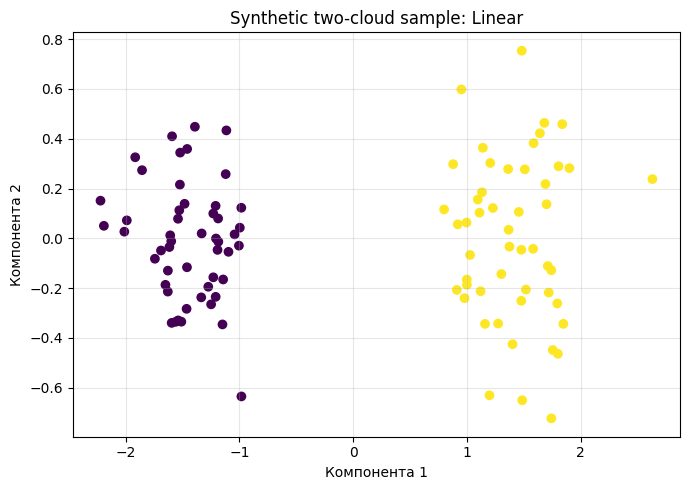

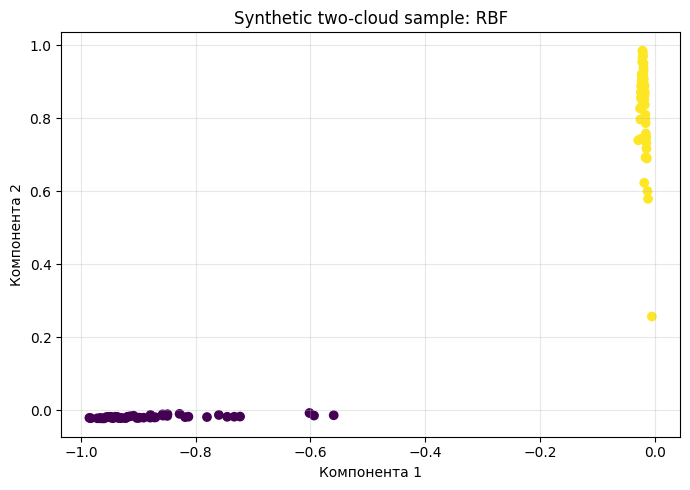

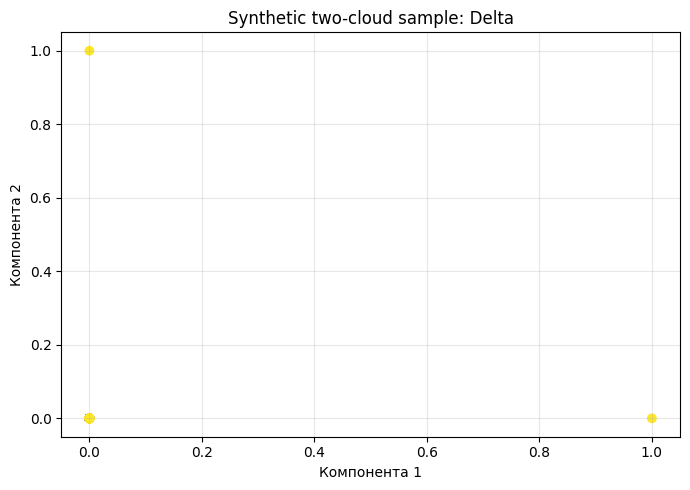

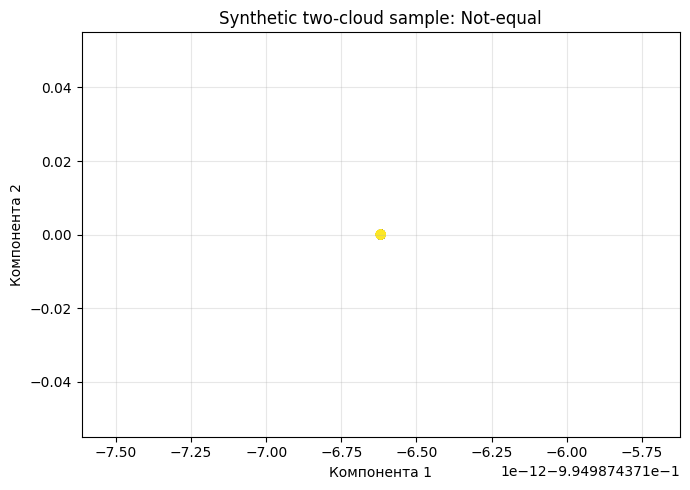

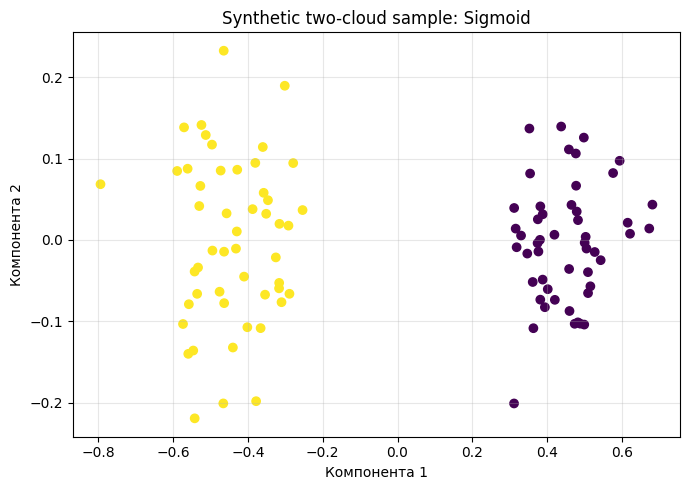

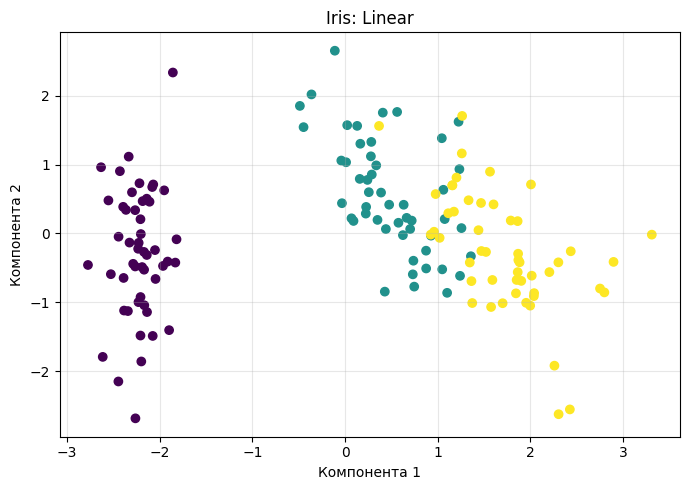

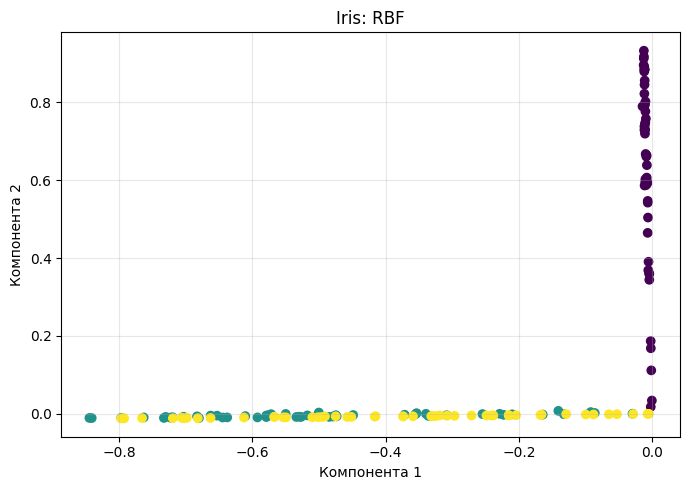

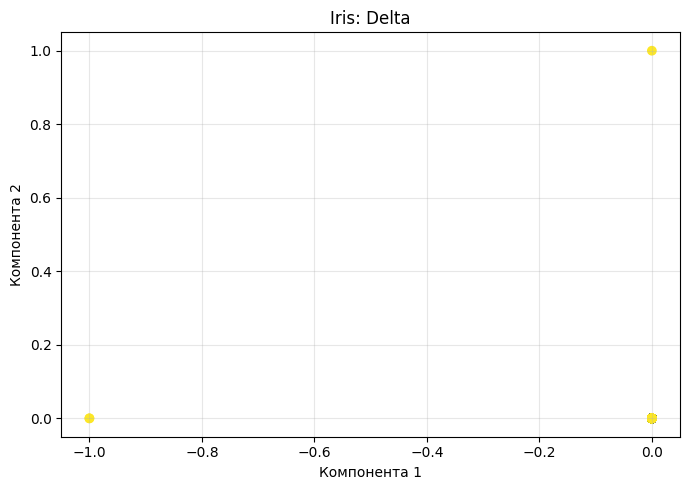

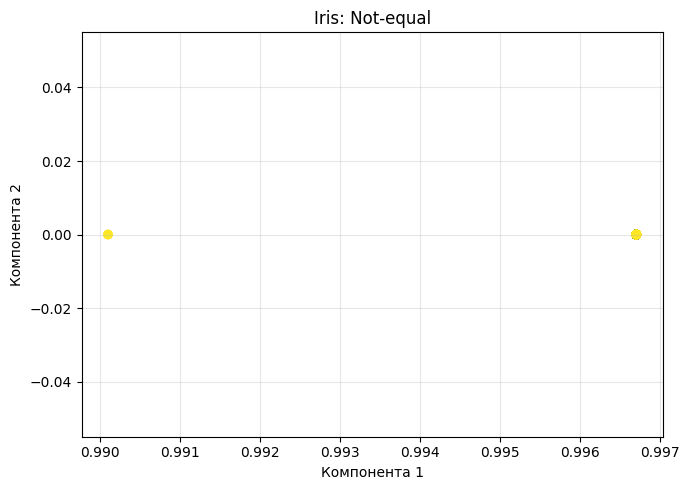

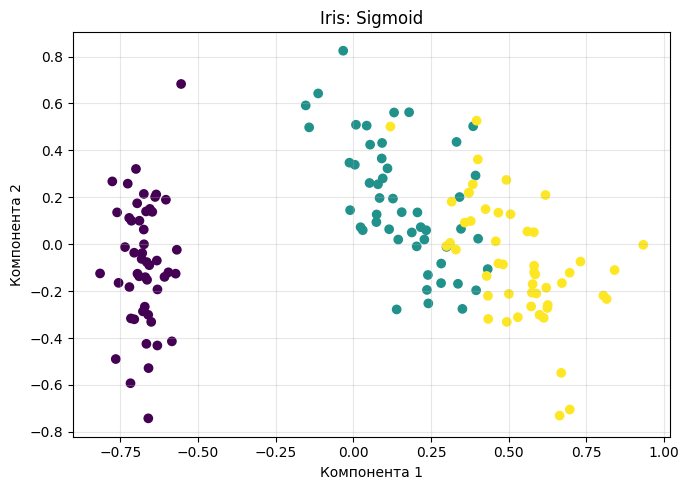

In [ ]:
for kernel_name, matrix in synthetic_result.gram_matrices.items():
    plot_spectral_embedding(
        matrix=matrix,
        labels=synthetic_dataset.labels,
        kernel_name=kernel_name,
        dataset_name=synthetic_dataset.name,
        config=config,
    )

for kernel_name, matrix in iris_result.gram_matrices.items():
    plot_spectral_embedding(
        matrix=matrix,
        labels=iris_dataset.labels,
        kernel_name=kernel_name,
        dataset_name=iris_dataset.name,
        config=config,
    )

## Финальная сводка

In [ ]:
final_summary = pd.concat(
    [synthetic_result.diagnostics, iris_result.diagnostics],
    ignore_index=True,
).merge(
    random_summary,
    on=["dataset", "kernel"],
    how="left",
    suffixes=("", "_random_summary"),
)

final_summary

,dataset,kernel,asymmetry_frobenius,lambda_min,negative_eigenvalues,spectral_mercer_passed,min_random_zTGz,random_test_passed,min,q01,median,mean,q99,max
0,Synthetic two-cloud sample,Linear,0.000000e+00,-5.538404e-14,0,True,0.001843,True,0.001843,0.010667,1.082928,2.318134,14.536735,20.750841
1,Synthetic two-cloud sample,RBF,0.000000e+00,-1.043826e-15,0,True,0.059313,True,0.059313,0.145202,0.789682,1.011980,3.418384,4.820340
2,Synthetic two-cloud sample,Delta,0.000000e+00,1.000000e+00,0,True,1.000000,True,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Synthetic two-cloud sample,Not-equal,0.000000e+00,-1.000000e+00,99,False,-0.999983,False,-0.999983,-0.999762,-0.551903,0.036288,5.522507,9.961339
4,Synthetic two-cloud sample,Sigmoid,1.717373e-15,-9.077263e-02,7,False,-0.007982,False,-0.007982,0.000217,0.101740,0.219890,1.341712,2.257741
5,Iris,Linear,0.000000e+00,-1.625917e-13,0,True,0.050098,True,0.050098,0.138027,2.592461,3.951586,21.263506,29.585156
6,Iris,RBF,0.000000e+00,4.737758e-17,0,True,0.352351,True,0.352351,0.445308,0.932248,1.007311,2.170443,2.856363
7,Iris,Delta,0.000000e+00,0.000000e+00,0,True,0.954191,True,0.954191,0.970203,0.999986,1.000437,1.036243,1.052230
8,Iris,Not-equal,0.000000e+00,-1.986754e+00,148,False,-1.029375,False,-1.029375,-1.005263,-0.535689,-0.020497,5.698602,8.604890
9,Iris,Sigmoid,3.428536e-15,-6.537464e-01,51,False,-0.030580,False,-0.030580,-0.012173,0.238666,0.342675,1.635623,2.589933
